# 🏭 Quản Lý Kho Hàng với Reinforcement Learning
## Inventory Management using RL (Q-Learning & DQN)

---

**Mô tả dự án:** Xây dựng hệ thống AI tự động quyết định **khi nào** và **bao nhiêu** hàng cần nhập vào kho để tối thiểu hóa tổng chi phí (chi phí tồn kho + chi phí thiếu hàng + chi phí đặt hàng).

**Thuật toán sử dụng:**
- 🧠 **Q-Learning** (Tabular RL)
- 🤖 **Deep Q-Network (DQN)** (Deep RL với Neural Network)

**So sánh với các chính sách cổ điển:**
- Random Policy
- Fixed Order Policy
- (s, S) Policy
- EOQ (Economic Order Quantity) Policy

**Môn học:** REL301m - Reinforcement Learning

## 1. 📦 Cài đặt và Import Thư viện

In [5]:
# Cài đặt thư viện (chạy 1 lần)
# !pip install numpy pandas matplotlib seaborn gymnasium torch tqdm scikit-learn openpyxl

import sys
import os
import warnings
warnings.filterwarnings('ignore')

# Thêm project root vào path
sys.path.insert(0, os.path.abspath('.'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
from tqdm.notebook import tqdm

# Thiết lập style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
matplotlib.rcParams['figure.figsize'] = (14, 6)
matplotlib.rcParams['font.size'] = 12

# Seed for reproducibility
np.random.seed(42)

print("✅ Tất cả thư viện đã được import thành công!")
print(f"   NumPy: {np.__version__}")
print(f"   Pandas: {pd.__version__}")
print(f"   PyTorch: ", end="")
try:
    import torch
    print(f"{torch.__version__} (CUDA: {torch.cuda.is_available()})")
except:
    print("Chưa cài đặt")
print(f"   Gymnasium: ", end="")
try:
    import gymnasium
    print(f"{gymnasium.__version__}")
except:
    print("Chưa cài đặt")

✅ Tất cả thư viện đã được import thành công!
   NumPy: 1.26.4
   Pandas: 2.3.3
   PyTorch: 2.9.0+cpu (CUDA: False)
   Gymnasium: 1.2.3


## 2. 📊 Tạo và Phân Tích Dữ Liệu Nhu Cầu Hàng Hóa (Demand Data)

Chúng ta sẽ tạo dữ liệu nhu cầu hàng hóa **realistic** với các đặc điểm:
- **Xu hướng theo mùa** (mùa hè/đông demand khác nhau)
- **Biến động theo tuần** (cuối tuần demand cao hơn)
- **Sự kiện đặc biệt** (Tết, Black Friday, sale)
- **Nhiễu ngẫu nhiên** (thực tế luôn có biến động)

In [6]:
from data.data_generator import generate_seasonal_demand, generate_realistic_warehouse_data, save_data

# Tạo và lưu toàn bộ dữ liệu
warehouse_data = save_data(data_dir="data", n_days=730, seed=42)

# Lấy demand data
demand_df = warehouse_data["demand"]
products_df = warehouse_data["products"]
suppliers_df = warehouse_data["suppliers"]

print(f"\n📋 Demand Data Shape: {demand_df.shape}")
print(f"📋 Products: {len(products_df)} sản phẩm")
print(f"📋 Suppliers: {len(suppliers_df)} nhà cung cấp")
demand_df.head(10)

✅ Đã lưu dữ liệu vào thư mục 'data/':
   - demand_data.csv (730 rows)
   - product_catalog.csv (10 products)
   - supplier_info.csv (5 suppliers)
   - multi_product_demand.csv (365 rows)

📋 Demand Data Shape: (730, 10)
📋 Products: 10 sản phẩm
📋 Suppliers: 5 nhà cung cấp


,date,demand,day_of_week,day_name,month,is_weekend,is_holiday,base_demand,seasonal_component,weekly_component
0,2024-01-01,47,0,Monday,1,0,0,30.0,15.0,0.0
1,2024-01-02,51,1,Tuesday,1,0,0,30.0,15.0,6.3
2,2024-01-03,56,2,Wednesday,1,0,0,30.0,15.0,7.8
3,2024-01-04,56,3,Thursday,1,0,0,30.0,15.0,3.5
4,2024-01-05,40,4,Friday,1,0,0,30.0,15.0,-3.5
5,2024-01-06,36,5,Saturday,1,1,0,30.0,14.9,-7.8
6,2024-01-07,47,6,Sunday,1,1,0,30.1,14.9,-6.3
7,2024-01-08,49,0,Monday,1,0,0,30.1,14.9,-0.0
8,2024-01-09,49,1,Tuesday,1,0,0,30.1,14.9,6.3
9,2024-01-10,55,2,Wednesday,1,0,0,30.1,14.8,7.8


In [ ]:
from data.data_generator import generate_seasonal_demand, generate_realistic_warehouse_data, save_data
from data.download_real_data import download_online_retail_data, process_retail_data_to_demand

# Bạn có 2 lựa chọn dữ liệu (Uncomment đoạn tương ứng)

# --- CÁCH 1: DÙNG DỮ LIỆU THUẬT TOÁN SYNTHETIC (MẶC ĐỊNH) ---
print("Đang tạo synthetic data...")
warehouse_data = save_data(data_dir="data", n_days=730, seed=42)
demand_df = warehouse_data["demand"]
products_df = warehouse_data["products"]
suppliers_df = warehouse_data["suppliers"]

# --- CÁCH 2: DÙNG DỮ LIỆU THẬT PUBLIC OLINE RETAIL ---
# print("Đang xử lý data thật từ public dataset...")
# excel_path = download_online_retail_data("data")
# demand_df = process_retail_data_to_demand(excel_path, "data")


print(f"\n📋 Demand Data Shape: {demand_df.shape}")
demand_df.head(10)

🏭 DANH MỤC SẢN PHẨM:


,product_id,product_name,unit_cost,holding_cost_per_unit,stockout_cost_per_unit,max_storage,shelf_life_days,category
0,P001,Gạo ST25 (kg),15,0.5,3.0,500,365,Lương thực
1,P002,Nước suối Aqua (thùng),80,1.0,5.0,200,180,Nước uống
2,P003,Mì Hảo Hảo (thùng),65,0.8,4.0,300,240,Lương thực
3,P004,Dầu Neptune (chai),45,0.6,3.0,200,365,Gia vị
4,P005,Sữa Vinamilk (thùng),120,1.5,7.0,150,30,Sữa
5,P006,Bia Saigon (thùng),200,2.0,10.0,100,180,Nước uống
6,P007,Bột giặt OMO (bịch),55,0.7,3.5,250,365,Tẩy rửa
7,P008,Nước mắm Chinsu (chai),25,0.4,2.0,300,365,Gia vị
8,P009,Cà phê G7 (hộp),90,1.0,5.0,200,180,Nước uống
9,P010,Bánh Orion (thùng),110,1.2,6.0,150,120,Bánh kẹo



🚛 NHÀ CUNG CẤP:


,supplier_id,supplier_name,lead_time_days,fixed_order_cost,min_order_qty,reliability
0,S01,Công ty Lương thực Miền Nam,2,50,50,0.95
1,S02,Đại lý nước giải khát Sài Gòn,1,30,20,0.98
2,S03,Nhà phân phối Acecook,3,40,30,0.92
3,S04,Công ty Dầu thực vật,2,35,20,0.96
4,S05,Vinamilk Distribution,1,45,10,0.99


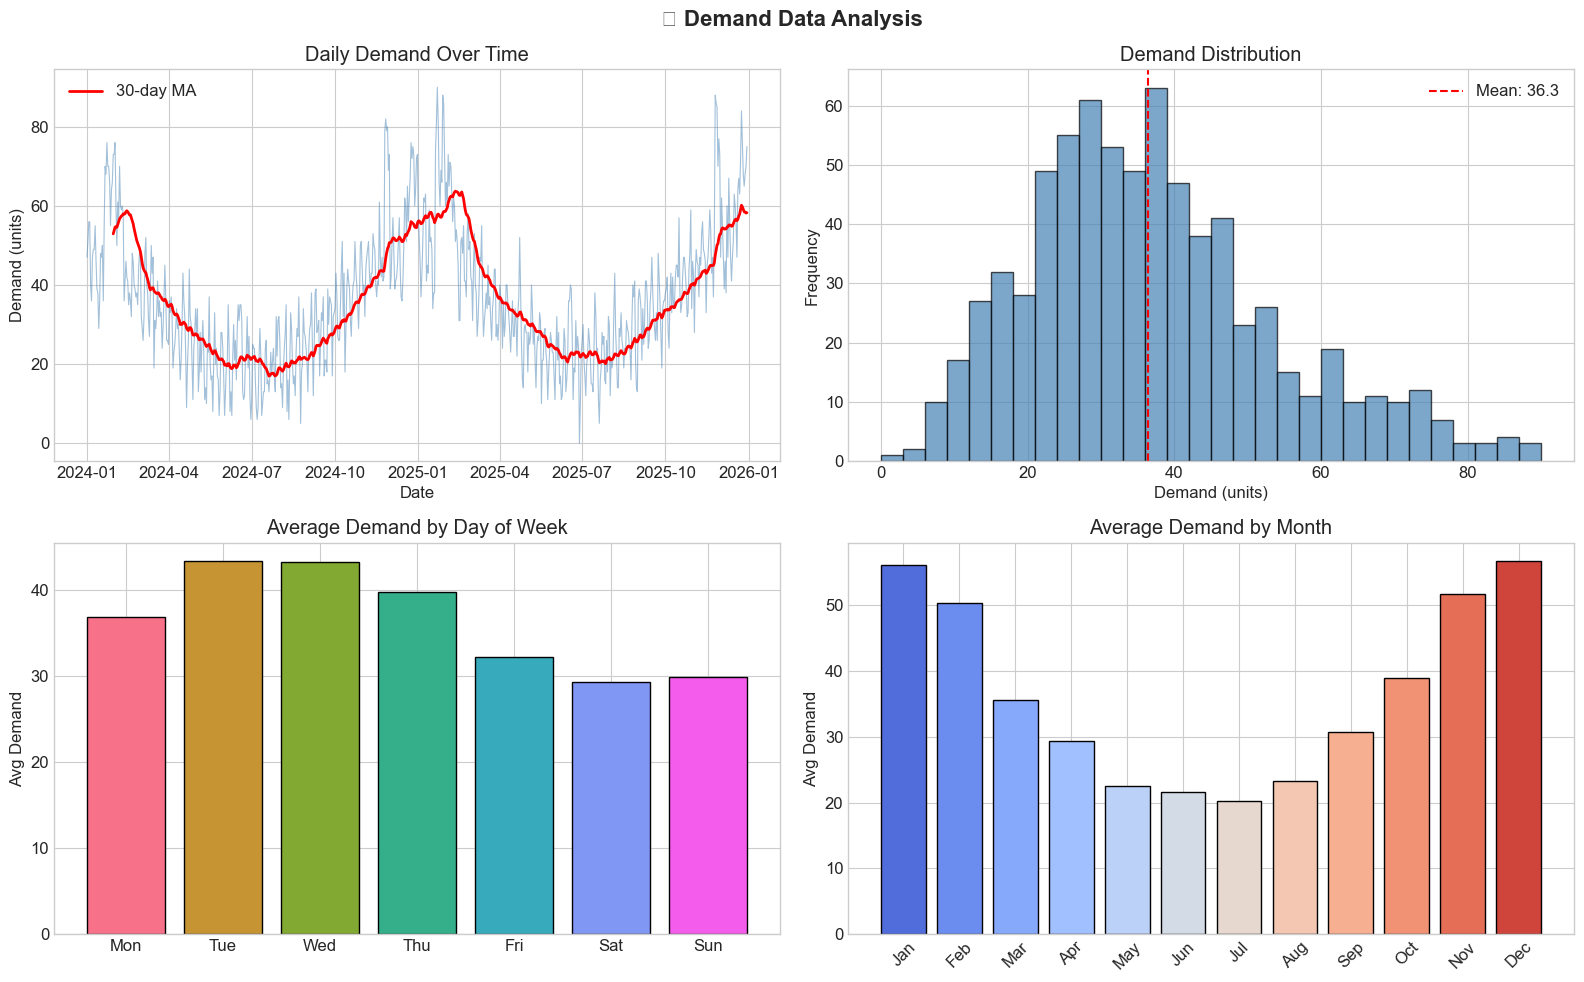

In [8]:
# 📊 PHÂN TÍCH DEMAND DATA
from utils.visualization import plot_demand_analysis
plot_demand_analysis(demand_df, save_path="figures/demand_analysis.png")

In [9]:
# Thống kê cơ bản về demand
print("📈 THỐNG KÊ DEMAND:")
print(f"   Trung bình: {demand_df['demand'].mean():.1f} units/ngày")
print(f"   Độ lệch chuẩn: {demand_df['demand'].std():.1f}")
print(f"   Min: {demand_df['demand'].min()}")
print(f"   Max: {demand_df['demand'].max()}")
print(f"   Tổng demand 2 năm: {demand_df['demand'].sum():,}")
print(f"\n   Ngày có demand cao nhất: {demand_df.loc[demand_df['demand'].idxmax(), 'date']}")
print(f"   Số ngày có sự kiện đặc biệt: {demand_df['is_holiday'].sum()}")

demand_df.describe()

📈 THỐNG KÊ DEMAND:
   Trung bình: 36.3 units/ngày
   Độ lệch chuẩn: 16.8
   Min: 0
   Max: 90
   Tổng demand 2 năm: 26,527

   Ngày có demand cao nhất: 2025-01-22 00:00:00
   Số ngày có sự kiện đặc biệt: 91


,date,demand,day_of_week,month,is_weekend,is_holiday,base_demand,seasonal_component,weekly_component
count,730,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000
mean,2024-12-30 12:00:00,36.338356,2.993151,6.512329,0.284932,0.124658,33.644932,-0.003836,0.008630
min,2024-01-01 00:00:00,0.000000,0.000000,1.000000,0.000000,0.000000,30.000000,-15.000000,-7.800000
25%,2024-07-01 06:00:00,24.000000,1.000000,4.000000,0.000000,0.000000,31.800000,-10.600000,-6.300000
50%,2024-12-30 12:00:00,34.000000,3.000000,7.000000,0.000000,0.000000,33.600000,0.100000,-0.000000
75%,2025-06-30 18:00:00,46.000000,5.000000,9.750000,1.000000,0.000000,35.500000,10.500000,6.300000
max,2025-12-30 00:00:00,90.000000,6.000000,12.000000,1.000000,1.000000,37.300000,15.000000,7.800000
std,NaN,16.824170,2.003072,3.448303,0.451691,0.330557,2.109163,10.615303,5.677414


## 3. 🎮 Thiết Lập Môi Trường RL (Environment)

Môi trường Inventory Management được xây dựng theo chuẩn **Gymnasium**:

| Thành phần | Mô tả |
|---|---|
| **State** | `[inventory_level, day_of_week, pending_orders, last_demand]` (normalized) |
| **Action** | Số lượng đặt hàng: `{0, 10, 20, ..., 100}` → 11 actions |
| **Reward** | `-(holding_cost + stockout_cost + order_cost)` |
| **Episode** | 365 ngày (1 năm kinh doanh) |

**Chi phí:**
- 💰 Holding cost: 1.0 / đơn vị / ngày (chi phí lưu kho)
- ❌ Stockout cost: 5.0 / đơn vị (chi phí thiếu hàng - mất khách)
- 🚚 Fixed order cost: 20.0 / lần đặt hàng
- 📦 Unit order cost: 2.0 / đơn vị đặt mua

In [10]:
from env.inventory_env import InventoryEnv

# Tạo demand array từ data
demand_array = demand_df["demand"].values

# Tạo environment
env = InventoryEnv(
    max_inventory=200,       # Sức chứa tối đa kho: 200 units
    max_order=100,           # Đặt hàng tối đa: 100 units/lần
    order_step=10,           # Bước đặt hàng: 10 units
    holding_cost=1.0,        # Chi phí tồn kho: 1.0/unit/ngày
    stockout_cost=5.0,       # Chi phí thiếu hàng: 5.0/unit
    fixed_order_cost=20.0,   # Chi phí cố định: 20.0/lần đặt
    unit_order_cost=2.0,     # Chi phí đặt hàng: 2.0/unit
    lead_time=1,             # Thời gian giao hàng: 1 ngày
    episode_length=365,      # 1 episode = 1 năm
    demand_data=demand_array,
    demand_type="real",      # Sử dụng demand data thật
)

print("✅ Environment đã được tạo!")
print(f"   Action Space: {env.action_space} ({env.n_actions} actions: 0, 10, 20, ..., 100)")
print(f"   Observation Space: {env.observation_space}")
print(f"   Episode Length: {env.episode_length} days")

# Test environment
state, _ = env.reset(seed=42)
print(f"\n   Initial State: {state}")
print(f"   Initial Inventory: {env.inventory}")

✅ Environment đã được tạo!
   Action Space: Discrete(11) (11 actions: 0, 10, 20, ..., 100)
   Observation Space: Box([-1.  0.  0.  0.], 1.0, (4,), float32)
   Episode Length: 365 days

   Initial State: [0.5 0.  0.  0. ]
   Initial Inventory: 100


## 4. 📏 Baseline Policies (Chính sách cơ bản để so sánh)

Trước khi huấn luyện RL, ta cần các **baseline** để so sánh:

1. **Random Policy**: Đặt hàng ngẫu nhiên → worst case
2. **Fixed Order Policy**: Đặt cùng 1 lượng mỗi ngày
3. **(s, S) Policy**: Khi tồn kho ≤ s → đặt lên mức S (chính sách cổ điển)
4. **EOQ Policy**: Sử dụng công thức Economic Order Quantity

In [11]:
from agents.baselines import RandomPolicy, FixedOrderPolicy, SsPolicyAgent, EOQPolicy
from train import evaluate_agent

n_actions = env.n_actions

# Tạo baseline policies
baselines = {
    "Random": RandomPolicy(n_actions),
    "Fixed Order (30/day)": FixedOrderPolicy(n_actions, fixed_action=3),
    "(s,S) Policy": SsPolicyAgent(n_actions, order_step=10, max_inventory=200, 
                                   reorder_point=0.3, order_up_to=0.8),
    "EOQ Policy": EOQPolicy(n_actions, order_step=10, max_inventory=200,
                             mean_demand=30.0, fixed_order_cost=20.0, holding_cost=1.0),
}

# Đánh giá baselines
baseline_results = {}
for name, policy in baselines.items():
    result = evaluate_agent(policy, env, n_episodes=10, seed=1000)
    baseline_results[name] = result
    print(f"  {name:25s} | Cost: {result['mean_cost']:>10,.0f} ± {result['std_cost']:>6,.0f} | "
          f"Stockout: {result['mean_stockout']:>6,.0f} | Reward: {result['mean_reward']:>10,.0f}")

print("\n✅ Baseline evaluation complete!")

  Random                    | Cost:     94,727 ±  1,925 | Stockout:    526 | Reward:    -94,727
  Fixed Order (30/day)      | Cost:     72,825 ±      0 | Stockout:  2,766 | Reward:    -72,825
  (s,S) Policy              | Cost:     61,186 ±      0 | Stockout:    548 | Reward:    -61,186
  EOQ Policy                | Cost:     61,186 ±      0 | Stockout:    548 | Reward:    -61,186

✅ Baseline evaluation complete!


## 5. 🧠 Huấn Luyện Q-Learning Agent

**Q-Learning** là thuật toán RL cơ bản sử dụng **Q-table** để lưu giá trị Q(s, a):

$$Q(s, a) \leftarrow Q(s, a) + \alpha \left[ r + \gamma \max_{a'} Q(s', a') - Q(s, a) \right]$$

Trong đó:
- $\alpha$: Learning rate (tốc độ học)
- $\gamma$: Discount factor (hệ số giảm giá)
- $\epsilon$: Exploration rate (tỷ lệ khám phá) - giảm dần theo thời gian

In [12]:
from agents.q_learning import QLearningAgent
from train import train_agent

# Tạo Q-Learning Agent
q_agent = QLearningAgent(
    n_actions=n_actions,
    n_bins=(20, 7, 5, 10),    # Discretize state thành bins
    learning_rate=0.1,         # Tốc độ học
    discount_factor=0.99,      # Discount factor
    epsilon_start=1.0,         # Bắt đầu explore 100%
    epsilon_end=0.01,          # Kết thúc explore 1%
    epsilon_decay=0.995,       # Giảm epsilon mỗi episode
)

print("🧠 Bắt đầu huấn luyện Q-Learning Agent...")
print(f"   Hyperparameters: lr={q_agent.lr}, gamma={q_agent.gamma}")
print(f"   Epsilon: {q_agent.epsilon_start} → {q_agent.epsilon_end}")
print(f"   State bins: {q_agent.n_bins}")
print()

# Huấn luyện 500 episodes
q_stats = train_agent(q_agent, env, n_episodes=500, verbose=True)

# Lưu model
os.makedirs("models", exist_ok=True)
q_agent.save("models/q_learning_model.pkl")

print(f"\n📊 Kết quả Q-Learning:")
print(f"   Best Reward: {q_stats['best_reward']:.0f}")
print(f"   Final Avg Reward (50 eps): {q_stats['final_avg_reward']:.0f}")
print(f"   Final Avg Cost (50 eps): {q_stats['final_avg_cost']:,.0f}")

🧠 Bắt đầu huấn luyện Q-Learning Agent...
   Hyperparameters: lr=0.1, gamma=0.99
   Epsilon: 1.0 → 0.01
   State bins: (20, 7, 5, 10)



Training: 100%|██████████| 500/500 [00:12<00:00, 38.95it/s, avg_reward=-75542, avg_cost=75,542, epsilon=0.085, best=-66058]

✅ Model saved to models/q_learning_model.pkl

📊 Kết quả Q-Learning:
   Best Reward: -66058
   Final Avg Reward (50 eps): -75225
   Final Avg Cost (50 eps): 75,225


## 6. 🤖 Huấn Luyện DQN Agent (Deep Q-Network)

**DQN** sử dụng **Neural Network** để xấp xỉ Q-function, thay vì Q-table:

**Cải tiến so với Q-Learning:**
- 🧠 Neural Network xấp xỉ Q(s,a) → xử lý state liên tục
- 📝 Experience Replay Buffer → ổn định training
- 🎯 Target Network → tránh overestimation
- ✂️ Gradient Clipping → ổn định gradient

In [13]:
from agents.dqn_agent import DQNAgent

# Tạo DQN Agent
dqn_agent = DQNAgent(
    state_dim=4,               # 4 features trong observation
    n_actions=n_actions,       # 11 actions
    hidden_dims=(128, 64),     # 2 hidden layers
    learning_rate=0.001,       # Adam optimizer lr
    discount_factor=0.99,
    epsilon_start=1.0,
    epsilon_end=0.01,
    epsilon_decay=0.995,
    batch_size=64,             # Batch size cho replay
    buffer_capacity=50000,     # Replay buffer size
    target_update_freq=10,     # Cập nhật target network mỗi 10 episodes
)

print(f"🤖 DQN Agent Architecture:")
print(f"   Device: {dqn_agent.device}")
print(f"   Network: Input(4) → Linear(128) → ReLU → Linear(64) → ReLU → Linear({n_actions})")
print(f"   Replay Buffer: {dqn_agent.replay_buffer.buffer.maxlen:,}")
print(f"   Batch Size: {dqn_agent.batch_size}")
print()

# Huấn luyện 500 episodes
dqn_stats = train_agent(dqn_agent, env, n_episodes=500, verbose=True)

# Lưu model
dqn_agent.save("models/dqn_model.pth")

print(f"\n📊 Kết quả DQN:")
print(f"   Best Reward: {dqn_stats['best_reward']:.0f}")
print(f"   Final Avg Reward (50 eps): {dqn_stats['final_avg_reward']:.0f}")


🤖 DQN Agent Architecture:
   Device: cpu
   Network: Input(4) → Linear(128) → ReLU → Linear(64) → ReLU → Linear(11)
   Replay Buffer: 50,000
   Batch Size: 64



Training: 100%|██████████| 500/500 [12:02<00:00,  1.44s/it, avg_reward=-45210, avg_cost=45,210, epsilon=0.085, best=-42750]

✅ DQN Model saved to models/dqn_model.pth

📊 Kết quả DQN:
   Best Reward: -42750
   Final Avg Reward (50 eps): -45188
   Final Avg Cost (50 eps): 45,188


## 7. 📈 Training Curves - Quá Trình Huấn Luyện

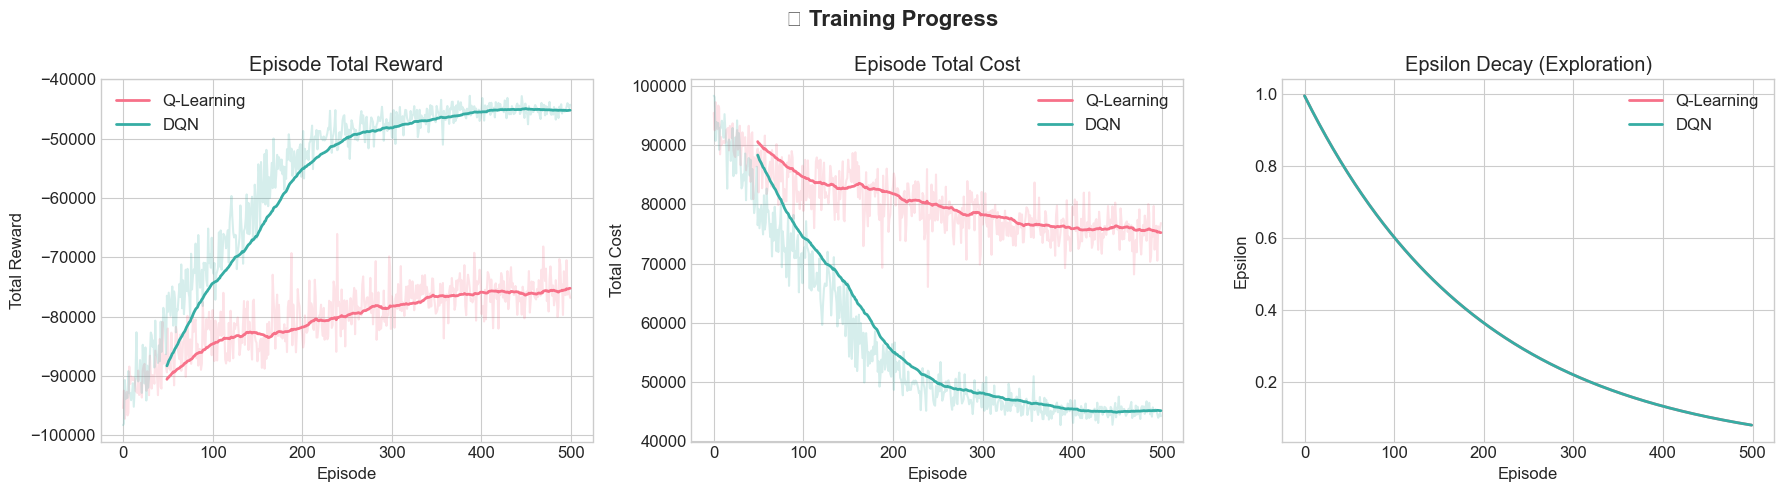

In [14]:
from utils.visualization import plot_training_curves

os.makedirs("figures", exist_ok=True)

# Vẽ training curves
agents_data = {
    "Q-Learning": {
        "rewards": q_agent.training_rewards,
        "costs": q_agent.training_costs,
        "epsilon_history": q_agent.epsilon_history,
    },
    "DQN": {
        "rewards": dqn_agent.training_rewards,
        "costs": dqn_agent.training_costs,
        "epsilon_history": dqn_agent.epsilon_history,
    },
}

plot_training_curves(agents_data, save_path="figures/training_curves.png")

## 8. 🏆 Đánh Giá và So Sánh Tất Cả Agents

So sánh hiệu quả giữa **RL agents** và **baseline policies** trên cùng bộ test.

In [15]:
from utils.visualization import plot_evaluation_comparison

# Đánh giá RL agents
q_eval = evaluate_agent(q_agent, env, n_episodes=10, seed=1000)
dqn_eval = evaluate_agent(dqn_agent, env, n_episodes=10, seed=1000)

# Tổng hợp tất cả kết quả
all_results = {**baseline_results}
all_results["Q-Learning"] = q_eval
all_results["DQN"] = dqn_eval

# Bảng so sánh
print("=" * 80)
print(f"{'🏆 BẢNG SO SÁNH HIỆU QUẢ CÁC AGENT/POLICY':^80}")
print("=" * 80)
print(f"{'Agent/Policy':<25} {'Avg Cost':>12} {'Std Cost':>10} {'Avg Stockout':>14} {'Avg Reward':>12}")
print("-" * 80)

for name, result in all_results.items():
    print(f"{name:<25} {result['mean_cost']:>12,.0f} {result['std_cost']:>10,.0f} "
          f"{result['mean_stockout']:>14,.0f} {result['mean_reward']:>12,.0f}")
print("=" * 80)

# Tìm agent tốt nhất
best_agent = min(all_results.items(), key=lambda x: x[1]['mean_cost'])
print(f"\n🥇 Agent tốt nhất (chi phí thấp nhất): {best_agent[0]} - Cost: {best_agent[1]['mean_cost']:,.0f}")

                    🏆 BẢNG SO SÁNH HIỆU QUẢ CÁC AGENT/POLICY                    
Agent/Policy                  Avg Cost   Std Cost   Avg Stockout   Avg Reward
--------------------------------------------------------------------------------
Random                          94,727      1,925            526      -94,727
Fixed Order (30/day)            72,825          0          2,766      -72,825
(s,S) Policy                    61,186          0            548      -61,186
EOQ Policy                      61,186          0            548      -61,186
Q-Learning                      72,461          0            925      -72,461
DQN                             43,731        491          2,441      -43,731

🥇 Agent tốt nhất (chi phí thấp nhất): DQN - Cost: 43,731


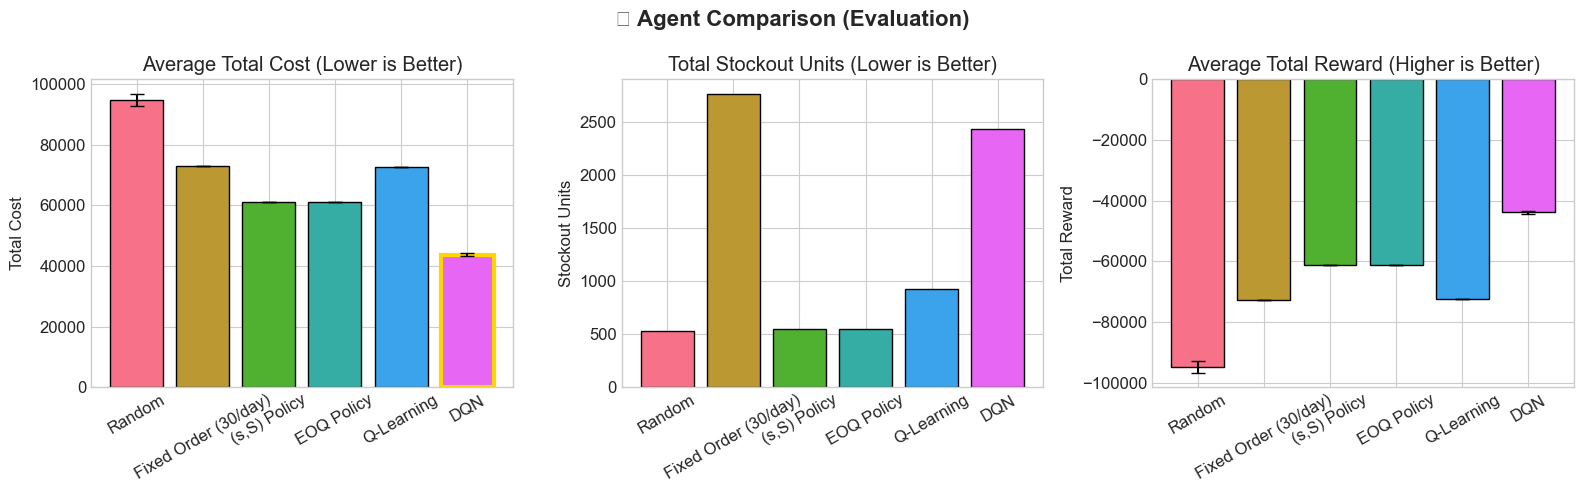

In [16]:
# Biểu đồ so sánh
plot_evaluation_comparison(all_results, save_path="figures/evaluation_comparison.png")

## 9. 🔍 Chi Tiết Mô Phỏng Kho Hàng (Simulation Visualization)

Xem chi tiết cách agent quản lý kho hàng trong 1 năm:
- Mức tồn kho qua từng ngày
- Demand vs Số lượng đặt hàng
- Phân tích chi phí hàng ngày
- Chi phí tích lũy

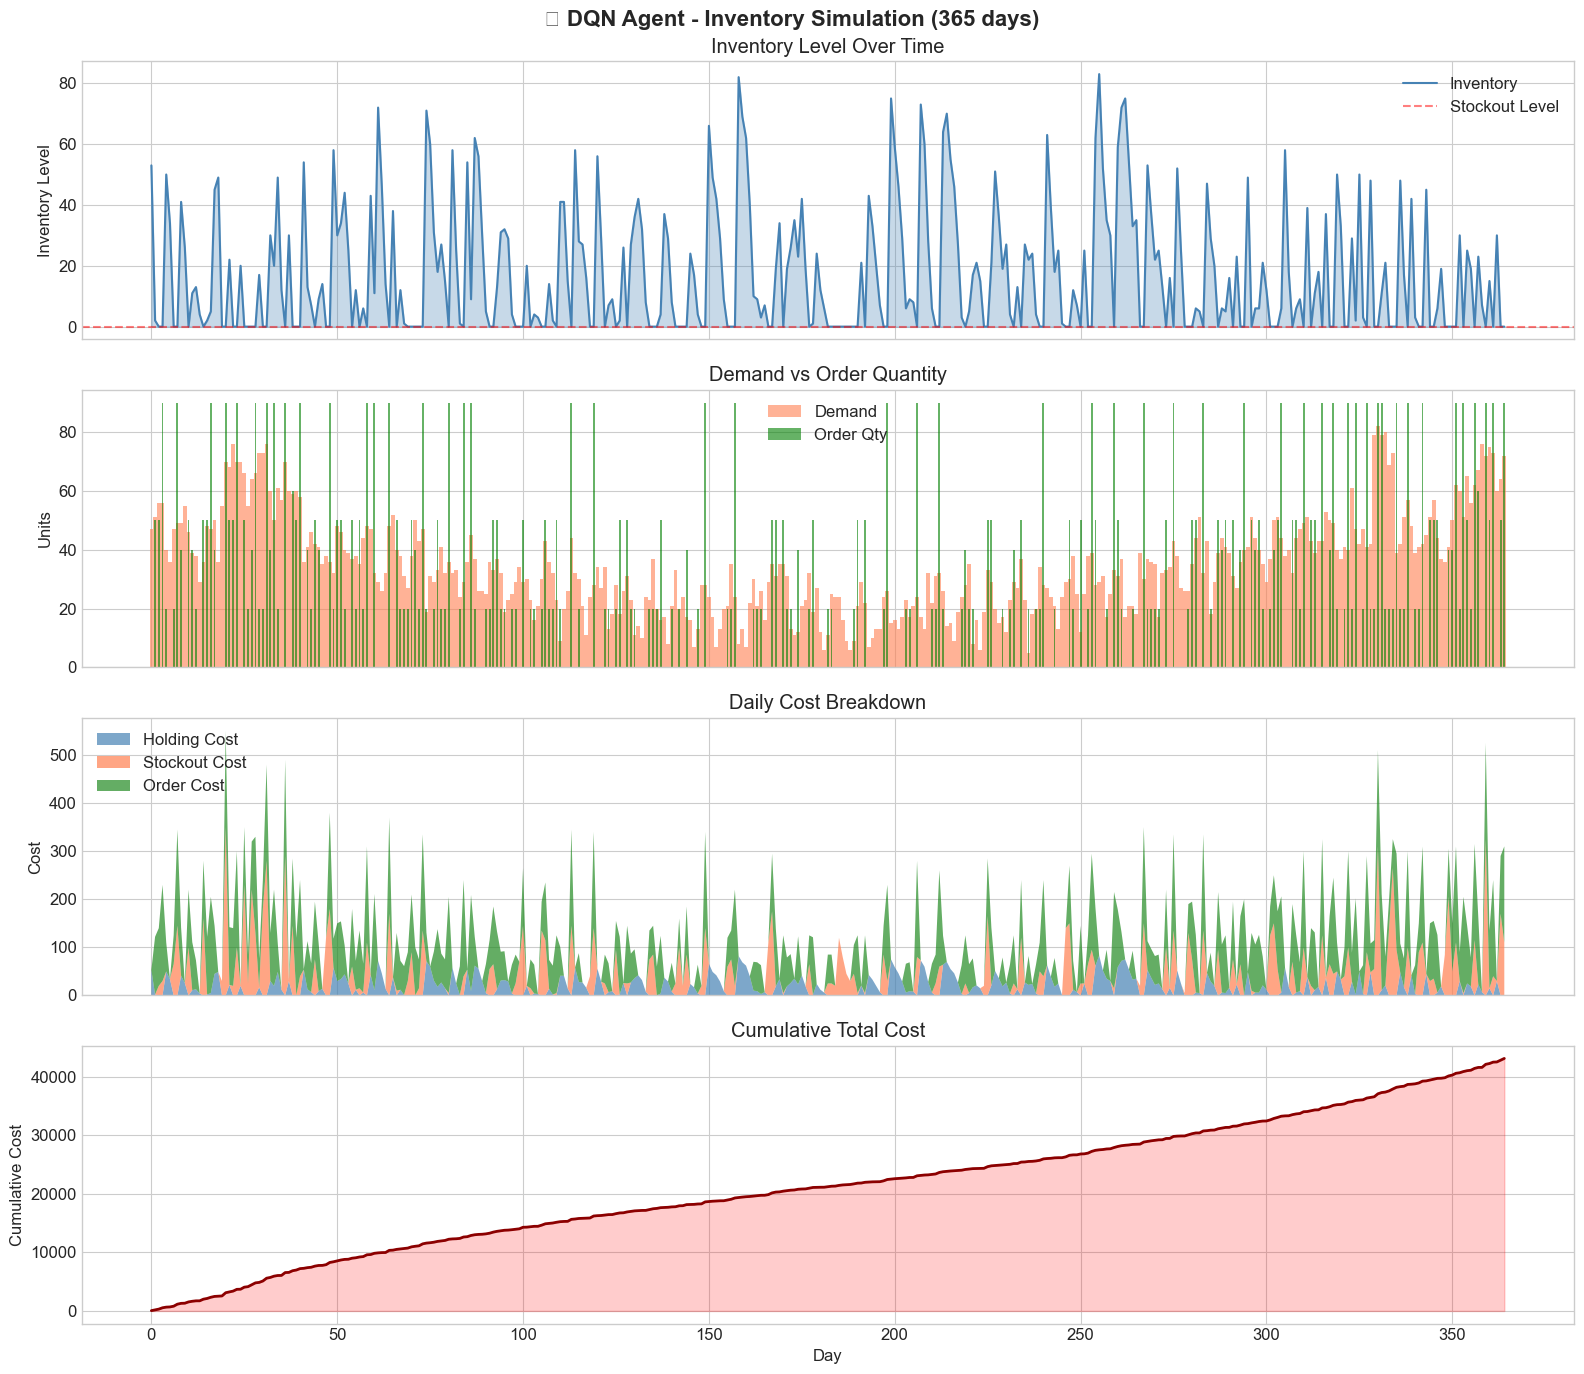

In [17]:
from utils.visualization import plot_inventory_simulation, plot_cost_breakdown_pie

# Chạy simulation với DQN agent
state, _ = env.reset(seed=42)
done = False
while not done:
    action = dqn_agent.select_action(state, training=False)
    state, reward, terminated, truncated, info = env.step(action)
    done = terminated or truncated

dqn_history = env.get_history_df()

# Vẽ chi tiết simulation
plot_inventory_simulation(dqn_history, title="DQN Agent - Inventory Simulation (365 days)",
                          save_path="figures/dqn_simulation.png")

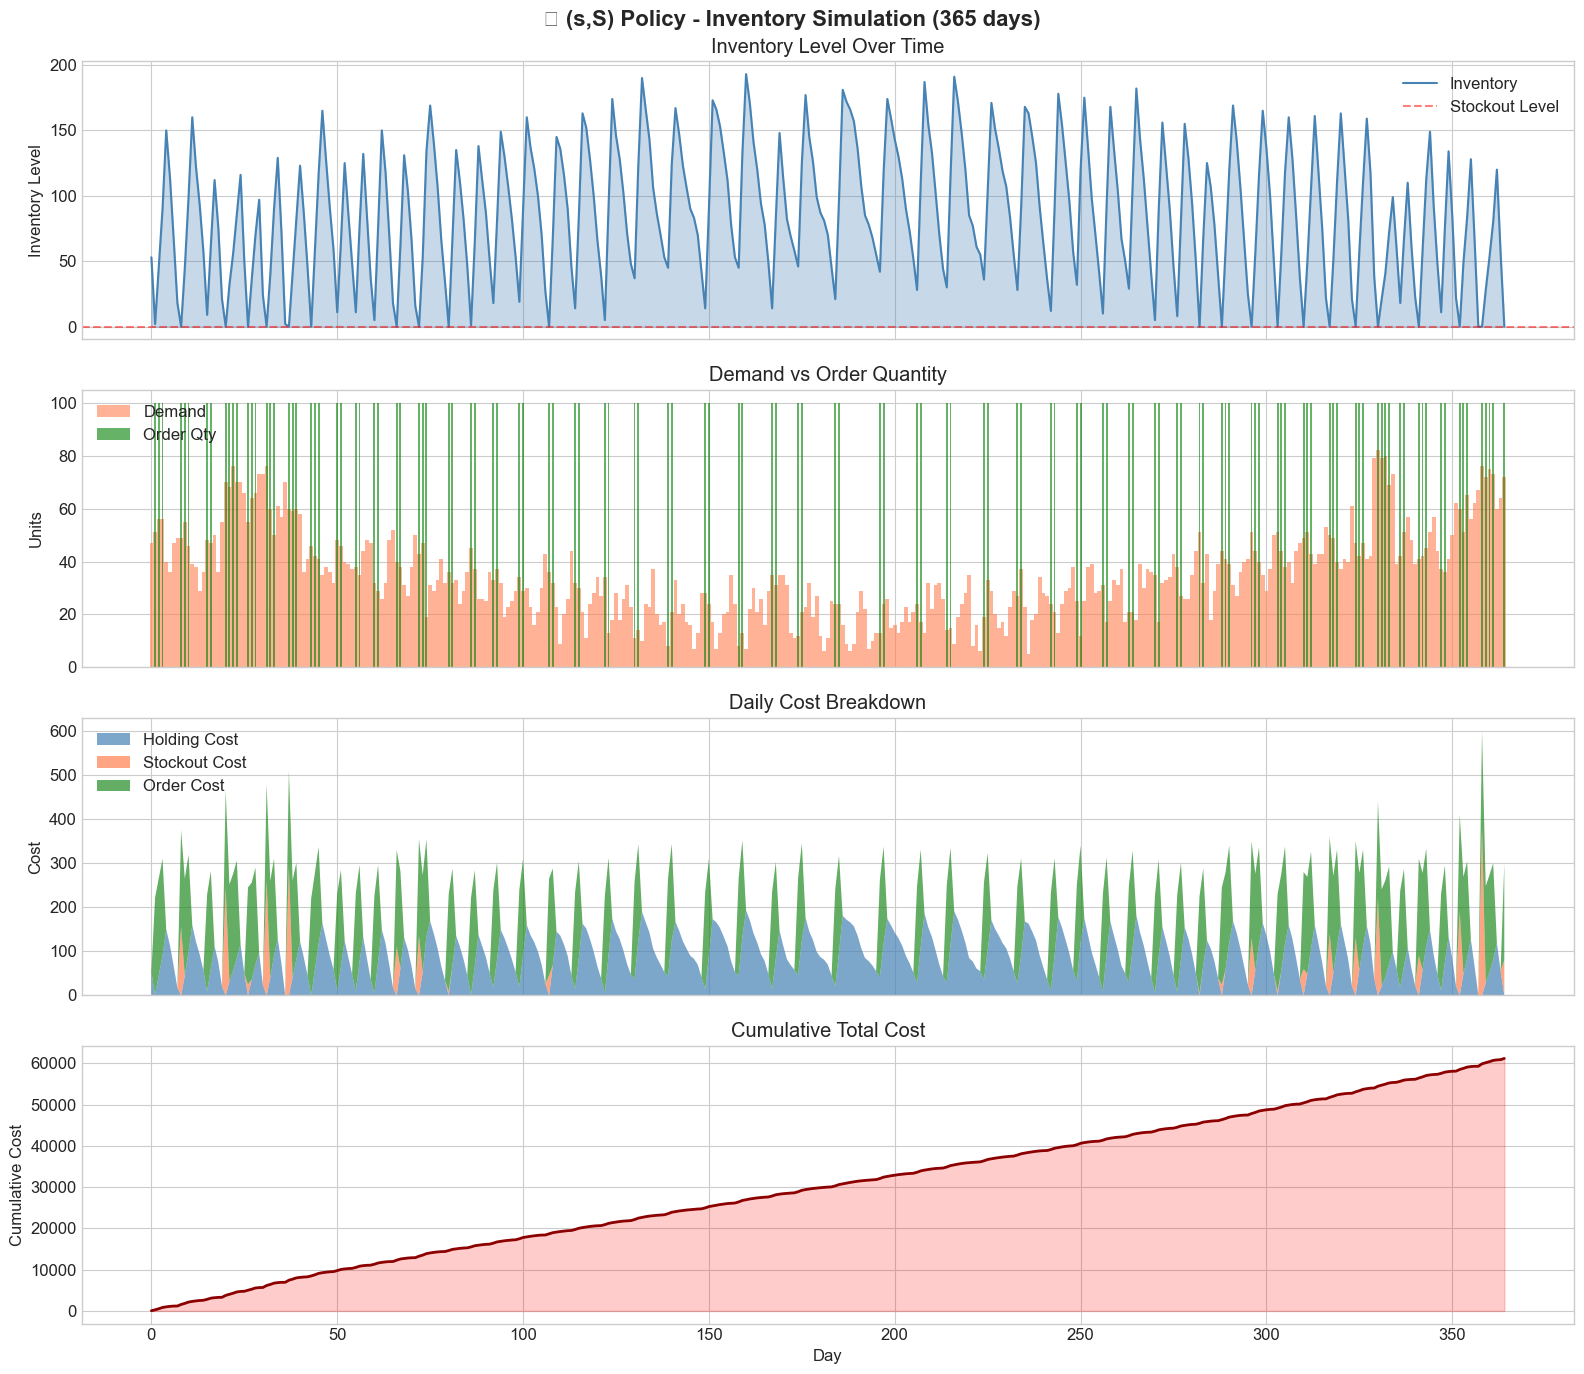

In [18]:
# So sánh simulation: DQN vs (s,S) Policy
state, _ = env.reset(seed=42)
ss_policy = baselines["(s,S) Policy"]
done = False
while not done:
    action = ss_policy.select_action(state, training=False)
    state, reward, terminated, truncated, info = env.step(action)
    done = terminated or truncated

ss_history = env.get_history_df()

plot_inventory_simulation(ss_history, title="(s,S) Policy - Inventory Simulation (365 days)",
                          save_path="figures/ss_simulation.png")

## 10. 🥧 Phân Tích Chi Phí Chi Tiết

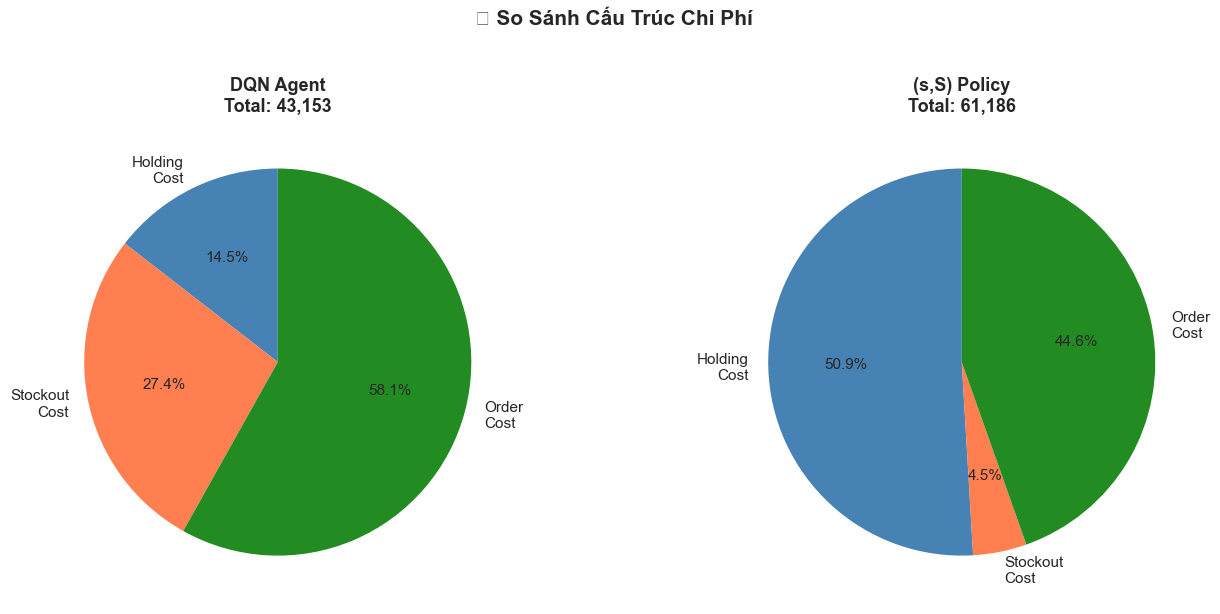


📊 CHI TIẾT CHI PHÍ:
Loại chi phí                  DQN        (s,S)   Chênh lệch
------------------------------------------------------------
Holding Cost                6,258       31,166      -24,908
Stockout Cost              11,815        2,740       +9,075
Order Cost                 25,080       27,280       -2,200
------------------------------------------------------------
TỔNG                       43,153       61,186      -18,033


In [19]:
# Phân tích chi phí DQN vs (s,S)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# DQN Cost Breakdown
ax = axes[0]
dqn_costs = [dqn_history["holding_cost"].sum(), dqn_history["stockout_cost"].sum(), dqn_history["order_cost"].sum()]
labels = ["Holding\nCost", "Stockout\nCost", "Order\nCost"]
colors = ['steelblue', 'coral', 'forestgreen']
wedges, texts, autotexts = ax.pie(dqn_costs, labels=labels, colors=colors, autopct='%1.1f%%', 
                                    startangle=90, textprops={'fontsize': 11})
ax.set_title(f"DQN Agent\nTotal: {sum(dqn_costs):,.0f}", fontsize=13, fontweight='bold')

# (s,S) Cost Breakdown
ax = axes[1]
ss_costs = [ss_history["holding_cost"].sum(), ss_history["stockout_cost"].sum(), ss_history["order_cost"].sum()]
wedges, texts, autotexts = ax.pie(ss_costs, labels=labels, colors=colors, autopct='%1.1f%%',
                                    startangle=90, textprops={'fontsize': 11})
ax.set_title(f"(s,S) Policy\nTotal: {sum(ss_costs):,.0f}", fontsize=13, fontweight='bold')

fig.suptitle("🥧 So Sánh Cấu Trúc Chi Phí", fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("figures/cost_breakdown.png", dpi=150, bbox_inches='tight')
plt.show()

# Chi tiết số liệu
print("\n📊 CHI TIẾT CHI PHÍ:")
print(f"{'Loại chi phí':<20} {'DQN':>12} {'(s,S)':>12} {'Chênh lệch':>12}")
print("-" * 60)
cost_types = ["holding_cost", "stockout_cost", "order_cost"]
cost_names = ["Holding Cost", "Stockout Cost", "Order Cost"]
for name, col in zip(cost_names, cost_types):
    d = dqn_history[col].sum()
    s = ss_history[col].sum()
    diff = d - s
    print(f"{name:<20} {d:>12,.0f} {s:>12,.0f} {diff:>+12,.0f}")
print("-" * 60)
print(f"{'TỔNG':<20} {dqn_history['daily_cost'].sum():>12,.0f} {ss_history['daily_cost'].sum():>12,.0f} "
      f"{dqn_history['daily_cost'].sum() - ss_history['daily_cost'].sum():>+12,.0f}")

## 11. 📋 Kết Luận

### Tóm tắt kết quả:

| Tiêu chí | Kết quả |
|---|---|
| **Bài toán** | Tối ưu hóa nhập hàng kho để minimize tổng chi phí |
| **Thuật toán RL** | Q-Learning (Tabular) và DQN (Deep RL) |
| **Baseline** | Random, Fixed Order, (s,S) Policy, EOQ |
| **Metric** | Total Cost, Stockout Rate, Total Reward |

### Nhận xét:
1. **RL agents** có khả năng học được chính sách nhập hàng hiệu quả
2. **DQN** thường tốt hơn Q-Learning nhờ Neural Network xử lý state liên tục
3. **(s,S) Policy** là baseline mạnh, nhưng RL có thể adapt theo pattern của demand
4. **RL agents** có thể giảm **stockout** (thiếu hàng) đáng kể so với baseline

### Hướng phát triển:
- 🔄 Thử nghiệm PPO, A2C (Policy Gradient methods)
- 📦 Multi-product inventory management
- 🌐 Multi-warehouse coordination
- 📈 Kết hợp demand forecasting + RL